left_eye_center_x            7039
left_eye_center_y            7039
right_eye_center_x           7036
right_eye_center_y           7036
left_eye_inner_corner_x      2271
left_eye_inner_corner_y      2271
left_eye_outer_corner_x      2267
left_eye_outer_corner_y      2267
right_eye_inner_corner_x     2268
right_eye_inner_corner_y     2268
right_eye_outer_corner_x     2268
right_eye_outer_corner_y     2268
left_eyebrow_inner_end_x     2270
left_eyebrow_inner_end_y     2270
left_eyebrow_outer_end_x     2225
left_eyebrow_outer_end_y     2225
right_eyebrow_inner_end_x    2270
right_eyebrow_inner_end_y    2270
right_eyebrow_outer_end_x    2236
right_eyebrow_outer_end_y    2236
nose_tip_x                   7049
nose_tip_y                   7049
mouth_left_corner_x          2269
mouth_left_corner_y          2269
mouth_right_corner_x         2270
mouth_right_corner_y         2270
mouth_center_top_lip_x       2275
mouth_center_top_lip_y       2275
mouth_center_bottom_lip_x    7016
mouth_center_b

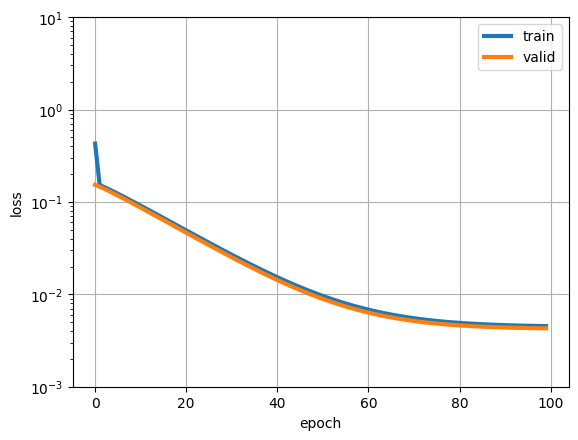

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from torch.utils.data import SubsetRandomSampler, DataLoader
import pandas as pd
import numpy as np
from sklearn.utils import shuffle
from collections import OrderedDict
import matplotlib.pyplot as plt
import os


# 資料路徑 Data Path
FTRAIN =  'data/training.csv'
FTEST =   'data/test.csv'
FLOOKUP = 'data/IdLookupTable.csv'

class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

class Dataset(torch.utils.data.Dataset):
    def __init__(self, test=False, cols=None):
        fname = FTEST if test else FTRAIN
        self.test = test
        df = pd.read_csv(fname)

        # Image 欄位 有像素的資料(pixel values) 轉換成  numpy arrays
        df['Image'] = df['Image'].apply(lambda im: np.fromstring(im, sep=' '))

        # 提取 特定欄位 相關的數據
        if cols:
            df = df[list(cols) + ['Image']]

        print(df.count()) # 資料集的筆數
        df = df.dropna()  # 刪除其中缺少值的資料

        self.X = np.vstack(df['Image'].values) / 255. # 將像素值進行歸一化 [0, 1]
        self.X = self.X.astype(np.float32) # 轉換資料型態

        if not test: # 只有 FTRAIN 有目標的標籤(label)
            self.y = df[df.columns[:-1]].values
            self.y = (self.y - 48) / 48
            self.X, self.y = shuffle(self.X, self.y, random_state=42) # 對資料進行 洗牌
            self.y = self.y.astype(np.float32)
        else:
            self.y = None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if not self.test:
            y = torch.tensor(self.y[idx],dtype=torch.float32)
            X = torch.tensor(self.X[idx],dtype=torch.float32)
            return X,y
        else:
            X = torch.tensor(self.X[idx],dtype=torch.float32)
            return X


class FCN(nn.Module):

    def __init__(self, num_classes = 30):
        super(FCN, self).__init__()
        self.fc1 = nn.Linear(9216, 100)
        self.bn1 = nn.BatchNorm1d(100)
        self.fc2 = nn.Linear(100, 30)
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def train(device,train_loader, model, criterion, optimizer):
    losses = AverageMeter()

    model.train()

    for i, (input, target) in enumerate(train_loader):
        input = input.to(device)
        target = target.to(device)
        optimizer.zero_grad()
        # compute output

        output = model(input)
        loss = criterion(output, target)

        losses.update(loss.item(), input.size(0))

        # compute gradient and do optimizing step

        loss.backward()
        optimizer.step()

    log = OrderedDict([('loss', losses.avg),])

    return log

def validate(device,train_loader, model, criterion):
    losses = AverageMeter()

    model.eval()
    with torch.no_grad():
        for i, (input, target) in enumerate(train_loader):
            input = input.to(device)
            target = target.to(device)

            # compute output

            output = model(input)
            loss = criterion(output, target)


            losses.update(loss.item(), input.size(0))


    log = OrderedDict([('loss', losses.avg),])

    return log

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

#optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=args.lr)

model = FCN().to(device)
model = nn.DataParallel(model)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss().to(device)
epochs = 100
dataset = Dataset()
dataSize = len(dataset)
indices = list(range(dataSize))
split = int(np.floor(0.2 * dataSize))
train_idx , val_idx = indices[split:], indices[:split]
train_sampler = SubsetRandomSampler(train_idx)
val_sampler = SubsetRandomSampler(val_idx)
train_loader = DataLoader(dataset, batch_size=128, sampler=train_sampler)
val_loader = DataLoader(dataset, batch_size=128, sampler=val_sampler)
train_log = list()
val_log = list()
for epoch in range(epochs):
    train_log.append(train(device, train_loader,model,criterion,optimizer)['loss'])
    val_log.append(validate(device, val_loader,model,criterion)['loss'])
    print("Epoch:{}/{} Train:{:.5f}\tval:{:.5f}\n".format(epoch + 1 ,epochs, train_log[-1], val_log[-1]))

torch.save(model, os.path.join('model_faceKeyPoint_'+ str(epochs) + '.pt'))
loss = train_log
val_loss = val_log

plt.plot(loss, linewidth=3, label='train')
plt.plot(val_loss, linewidth=3, label='valid')
plt.grid()
plt.legend()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.ylim(1e-3, 1e+1)
plt.yscale('log')
plt.show()

ImageId    1783
Image      1783
dtype: int64


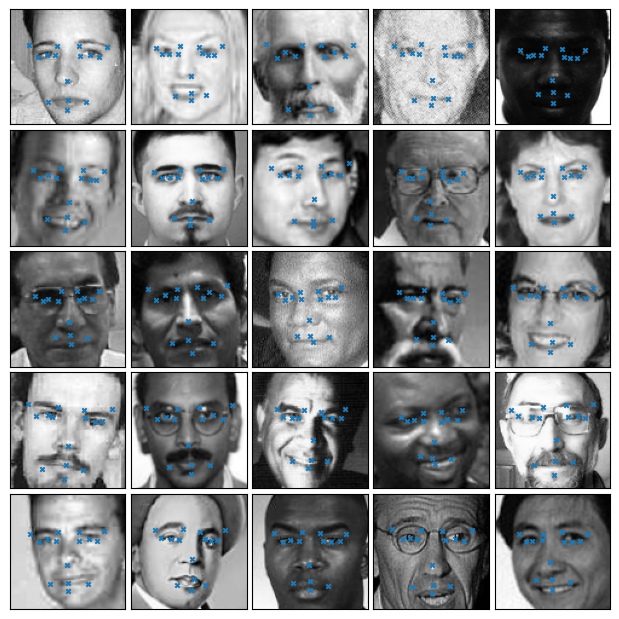

In [3]:
def plot_sample(x, y, axis):
    img = x.reshape(96, 96)
    axis.imshow(img, cmap='gray')
    axis.scatter(y[0::2] * 48 + 48, y[1::2] * 48 + 48, marker='x', s=10)

testset = Dataset(test=True)

test_loader = DataLoader(testset, batch_size=128)
model.eval()
input = None
y_pred = None
with torch.no_grad():
    for i, (input) in enumerate(test_loader):
        input = input.to(device)
        y_pred = model(input).cpu().numpy()
        input = input.cpu().numpy()


fig = plt.figure(figsize=(6, 6))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)


for i in range(25):
    ax = fig.add_subplot(5, 5, i + 1, xticks=[], yticks=[])
    plot_sample (input[i], y_pred[i], ax)

left_eye_center_x            7039
left_eye_center_y            7039
right_eye_center_x           7036
right_eye_center_y           7036
left_eye_inner_corner_x      2271
left_eye_inner_corner_y      2271
left_eye_outer_corner_x      2267
left_eye_outer_corner_y      2267
right_eye_inner_corner_x     2268
right_eye_inner_corner_y     2268
right_eye_outer_corner_x     2268
right_eye_outer_corner_y     2268
left_eyebrow_inner_end_x     2270
left_eyebrow_inner_end_y     2270
left_eyebrow_outer_end_x     2225
left_eyebrow_outer_end_y     2225
right_eyebrow_inner_end_x    2270
right_eyebrow_inner_end_y    2270
right_eyebrow_outer_end_x    2236
right_eyebrow_outer_end_y    2236
nose_tip_x                   7049
nose_tip_y                   7049
mouth_left_corner_x          2269
mouth_left_corner_y          2269
mouth_right_corner_x         2270
mouth_right_corner_y         2270
mouth_center_top_lip_x       2275
mouth_center_top_lip_y       2275
mouth_center_bottom_lip_x    7016
mouth_center_b

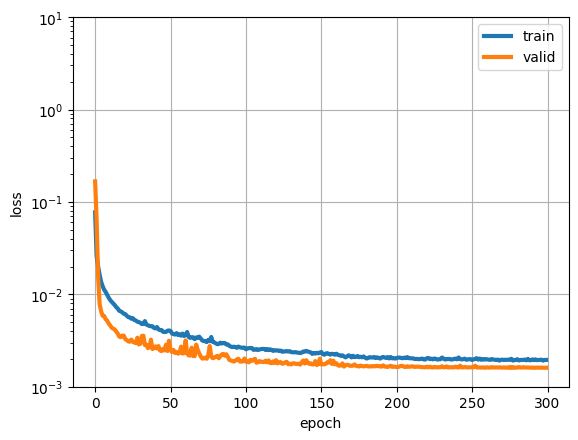

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from torch.utils.data import SubsetRandomSampler, DataLoader
import pandas as pd
import numpy as np
from sklearn.utils import shuffle
from collections import OrderedDict
import matplotlib.pyplot as plt
import os
epochs = 300
class cnn_model(nn.Module):

    def __init__(self):
        super().__init__()
        # 兩個卷積層（新增的兩層運算），搭配池化讓維度不爆炸
        # 輸入: (B, 1, 96, 96)
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # (B, 32, 96, 96)
            nn.BatchNorm2d(32),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(2),                               # (B, 32, 48, 48)
            nn.Dropout2d(p=0.2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # (B, 64, 48, 48)
            nn.BatchNorm2d(64),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(2),                               # (B, 64, 24, 24)
            nn.Dropout2d(p=0.2),

            # 擴大感受野但保留解析度（不使用池化）的 dilation 卷積區塊
            nn.Conv2d(64, 64, kernel_size=3, padding=2, dilation=2, stride=1),  # (B, 64, 24, 24)
            nn.BatchNorm2d(64),
            nn.SiLU(inplace=True),
            nn.Dropout2d(p=0.2),
        )

        self.pool = nn.AdaptiveAvgPool2d(6)

        self.regressor = nn.Sequential(
            nn.Flatten(),                                  # (B, 64*6*6)
            nn.Linear(64 * 6 * 6, 256),
            nn.SiLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, 30)
        )

    def forward(self, x):
        # x: (B,1,96,96)
        x = (x - 0.5) / 0.5
        # CoordConv：為輸入拼接歸一化的 (x,y) 座標通道，提昇定位能力
        B, C, H, W = x.shape
        yy, xx = torch.meshgrid(
            torch.linspace(-1.0, 1.0, H, device=x.device, dtype=x.dtype),
            torch.linspace(-1.0, 1.0, W, device=x.device, dtype=x.dtype),
            indexing='ij'
        )
        coord = torch.stack((xx, yy), dim=0).unsqueeze(0).expand(B, -1, -1, -1)  # (B,2,H,W)
        x = torch.cat([x, coord], dim=1)  # (B,3,H,W)
        x = self.features(x)
        x = self.pool(x)
        x = self.regressor(x)
        return x

class Dataset2d(torch.utils.data.Dataset):
    def __init__(self, test=False, cols=None):
        fname = FTEST if test else FTRAIN
        self.test = test
        df = pd.read_csv(fname)

        # Image 欄位 有像素的資料(pixel values) 轉換成  numpy arrays
        df['Image'] = df['Image'].apply(lambda im: np.fromstring(im, sep=' '))

        # 提取 特定欄位 相關的數據
        if cols:
            df = df[list(cols) + ['Image']]

        print(df.count()) # 資料集的筆數
        df = df.dropna()  # 刪除其中缺少值的資料

        self.X = np.vstack(df['Image'].values) / 255. # 將像素值進行歸一化 [0, 1]
        self.X = self.X.astype(np.float32) # 轉換資料型態

        if not test: # 只有 FTRAIN 有目標的標籤(label)
            self.y = df[df.columns[:-1]].values
            self.y = (self.y - 48) / 48
            self.X, self.y = shuffle(self.X, self.y, random_state=42) # 對資料進行 洗牌
            self.y = self.y.astype(np.float32)
        else:
            self.y = None
        #self.X = self.X.reshape(-1, 1, 96, 96)
        self.X = self.X.reshape(-1, 96, 96, 1) # 轉換成 Conv2D的卷積層 的 input shape
        self.X = self.X.transpose((0,3,1,2))
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if not self.test:
            y = torch.tensor(self.y[idx],dtype=torch.float32)
            X = torch.tensor(self.X[idx],dtype=torch.float32)
            return X,y
        else:
            X = torch.tensor(self.X[idx],dtype=torch.float32)
            return X

def train(device,train_loader, model, criterion, optimizer):
    losses = AverageMeter()

    model.train()

    for i, (input, target) in enumerate(train_loader):
        input = input.to(device)
        target = target.to(device)
        optimizer.zero_grad()
        # 輕量影像增強：亮度抖動 + 高斯雜訊（不改變關鍵點語義）
        with torch.no_grad():
            # brightness in [0.9, 1.1]
            b = 0.9 + 0.2 * torch.rand(input.size(0), 1, 1, 1, device=input.device, dtype=input.dtype)
            input = torch.clamp(input * b, 0.0, 1.0)
            # additive gaussian noise (std≈0.02)
            input = torch.clamp(input + 0.02 * torch.randn_like(input), 0.0, 1.0)
        # compute output

        output = model(input)
        loss = criterion(output, target)

        losses.update(loss.item(), input.size(0))

        # compute gradient and do optimizing step

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

    log = OrderedDict([('loss', losses.avg),])

    return log

def validate(device,train_loader, model, criterion):
    losses = AverageMeter()

    model.eval()
    with torch.no_grad():
        for i, (input, target) in enumerate(train_loader):
            input = input.to(device)
            target = target.to(device)

            # compute output

            output = model(input)
            loss = criterion(output, target)


            losses.update(loss.item(), input.size(0))


    log = OrderedDict([('loss', losses.avg),])

    return log


model2 = cnn_model().to(device)
model2 = nn.DataParallel(model2)
dataset = Dataset2d()
dataSize = len(dataset)
indices = list(range(dataSize))
split = int(np.floor(0.2 * dataSize))
train_idx , val_idx = indices[split:], indices[:split]
train_sampler = SubsetRandomSampler(train_idx)
val_sampler = SubsetRandomSampler(val_idx)
train_loader = DataLoader(dataset, batch_size=256, sampler=train_sampler)
val_loader = DataLoader(dataset, batch_size=512, sampler=val_sampler)
train_log = list()
val_log = list()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model2.parameters()), lr=7e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=12, min_lr=1e-6)
prev_lr = optimizer.param_groups[0]['lr']
#optimizer = optim.SGD(filter(lambda p: p.requires_grad, model2.parameters()), lr=0.01,momentum=0.9, nesterov=True)

#SmoothL1Loss(=Huber)，對離群點更穩；beta 可在 0.2~1.0 間微調，越小越接近 L1，越大越接近 L2
criterion = nn.SmoothL1Loss(beta=0.3, reduction='mean').to(device)

for epoch in range(epochs):
    train_log.append(train(device, train_loader,model2,criterion,optimizer)['loss'])
    val_log.append(validate(device, val_loader,model2,criterion)['loss'])
    scheduler.step(val_log[-1])
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != prev_lr:
        print(f"[scheduler] ReduceLROnPlateau: lr reduced to {new_lr:.6g} at epoch {epoch+1}")
        prev_lr = new_lr
    print("Epoch:{}/{} Train:{:.5f}\tval:{:.5f}\n".format(epoch + 1 ,epochs, train_log[-1], val_log[-1]))

torch.save(model2, os.path.join('model_faceKeyPoint_cnn_'+ str(epochs) + '.pt'))
loss = train_log
val_loss = val_log

plt.plot(loss, linewidth=3, label='train')
plt.plot(val_loss, linewidth=3, label='valid')
plt.grid()
plt.legend()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.ylim(1e-3, 1e+1)
plt.yscale('log')
plt.show()

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from torch.utils.data import SubsetRandomSampler, DataLoader
import pandas as pd
import numpy as np
from sklearn.utils import shuffle
from collections import OrderedDict
import matplotlib.pyplot as plt
import os


FTRAIN =  'data/training.csv'
FTEST =   'data/test.csv'
FLOOKUP = 'data/IdLookupTable.csv'
fname =  FTEST

df = pd.read_csv(fname)

# Image 欄位 有像素的資料(pixel values) 轉換成  numpy arrays
df['Image'] = df['Image'].apply(lambda im: np.fromstring(im, sep=' '))

# 提取 特定欄位 相關的數據
#print(df.count()) # 資料集的筆數
df = df.dropna()  # 刪除其中缺少值的資料

X = np.vstack(df['Image'].values) / 255. # 將像素值進行歸一化 [0, 1]
X = X.astype(np.float32) # 轉換資料型態
print(X)


[[0.7137255  0.7176471  0.7137255  ... 0.03137255 0.01960784 0.01960784]
 [0.29803923 0.34117648 0.31764707 ... 0.89411765 0.827451   0.65882355]
 [0.69411767 0.6901961  0.68235296 ... 0.00392157 0.00392157 0.00392157]
 ...
 [0.10980392 0.10980392 0.11372549 ... 0.3019608  0.30588236 0.30588236]
 [0.40784314 0.37254903 0.2784314  ... 0.5647059  0.5921569  0.62352943]
 [0.24705882 0.23921569 0.2509804  ... 0.44313726 0.4392157  0.44313726]]


ImageId    1783
Image      1783
dtype: int64


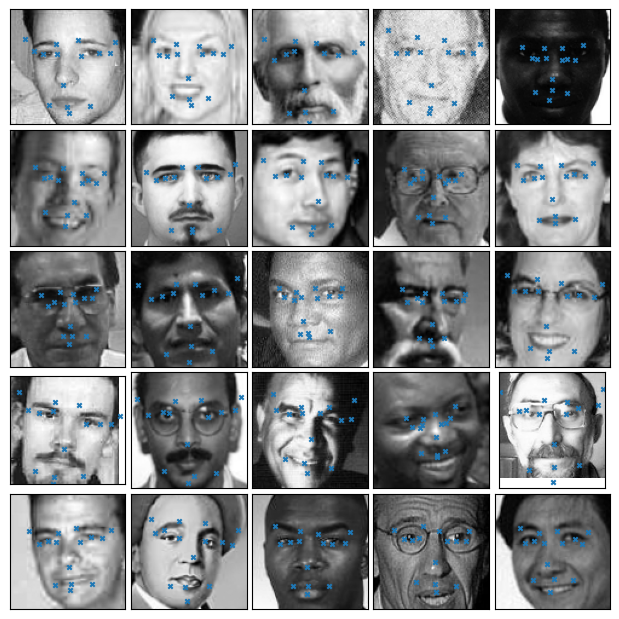

In [13]:
def plot_sample(x, y, axis):
    img = x.reshape(96, 96)
    axis.imshow(img, cmap='gray')
    axis.scatter(y[0::2] * 48 + 48, y[1::2] * 48 + 48, marker='x', s=10)

testset = Dataset2d(test=True)

test_loader = DataLoader(testset, batch_size=128)
model.eval()
input = None
y_pred2 = None
with torch.no_grad():
    for i, (input) in enumerate(test_loader):
        input = input.to(device)
        y_pred2 = model2(input).cpu().numpy()
        input = input.cpu().numpy()


fig = plt.figure(figsize=(6, 6))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)


for i in range(25):
    ax = fig.add_subplot(5, 5, i + 1, xticks=[], yticks=[])
    plot_sample (input[i], y_pred2[i], ax)

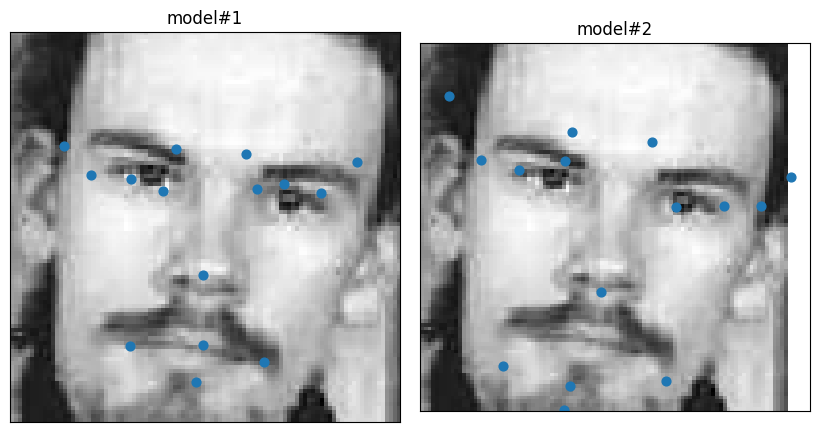

In [14]:
def plot_sample(x, y, axis):
    img = x.reshape(96, 96)       # 圖像是 96x96
    axis.imshow(img, cmap='gray') # 以灰階來顯示

    # 模型預測出來的 15個臉部關鍵點 列印在圖像上
    axis.scatter(y[0::2] * 48 + 48, y[1::2] * 48 + 48, marker='o', s=40)

fig = plt.figure(figsize=(8, 8))

idx = 15 # 找一張圖像 來比較兩個模型 預測的結果

fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

# 第一個 模型

ax = fig.add_subplot(1, 2, 1, xticks=[], yticks=[])
ax.set_title('model#1')
plot_sample(input[idx], y_pred[idx], ax)

# 第二個 模型
ax = fig.add_subplot(1, 2, 2, xticks=[], yticks=[])
ax.set_title('model#2')
plot_sample(input[idx], y_pred2[idx], ax)

plt.show()

---
## 作業實作：Haar Face Detection + Face Key Point Detection

### 要求
結合 Haar Face Detection 與 Face Key Point Detection，將臉部關鍵點標記在原圖上

> 注意事項：
> - 確保已訓練好模型：`model_faceKeyPoint_cnn_300.pt`
> - 可更換測試圖片：`Obama.jpg`, `donald_trump.jpg`, `captin_marvel.jpg` 等

In [9]:
import torch
import torch.nn as nn

device = torch.device("mps" if torch.backends.mps.is_available() else 'cpu')

# 若尚未定義，補上 cnn_model 類別，供反序列化使用
if 'cnn_model' not in globals():
    class cnn_model(nn.Module):
        def __init__(self):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32),
                nn.SiLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Dropout2d(p=0.2),

                nn.Conv2d(32, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64),
                nn.SiLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Dropout2d(p=0.2),

                nn.Conv2d(64, 64, kernel_size=3, padding=2, dilation=2, stride=1),
                nn.BatchNorm2d(64),
                nn.SiLU(inplace=True),
                nn.Dropout2d(p=0.2),
            )

            self.pool = nn.AdaptiveAvgPool2d(6)

            self.regressor = nn.Sequential(
                nn.Flatten(),
                nn.Linear(64 * 6 * 6, 256),
                nn.SiLU(inplace=True),
                nn.Dropout(0.2),
                nn.Linear(256, 30)
            )

        def forward(self, x):
            x = (x - 0.5) / 0.5
            B, C, H, W = x.shape
            yy, xx = torch.meshgrid(
                torch.linspace(-1.0, 1.0, H, device=x.device, dtype=x.dtype),
                torch.linspace(-1.0, 1.0, W, device=x.device, dtype=x.dtype),
                indexing='ij'
            )
            coord = torch.stack((xx, yy), dim=0).unsqueeze(0).expand(B, -1, -1, -1)
            x = torch.cat([x, coord], dim=1)
            x = self.features(x)
            x = self.pool(x)
            x = self.regressor(x)
            return x

checkpoint_path = 'model_faceKeyPoint_cnn_300.pt'
check = torch.load(checkpoint_path, map_location=device, weights_only=False)

if isinstance(check, torch.nn.DataParallel):
    state = check.module.state_dict()
else: 
    try: 
        state = check.state_dict()
    except:
        state = check.get('module.state_dict', check.get('state_dict', check)) #用except找常見鍵

torch.save(state, 'model.pth')

/var/folders/8_/tqzlktmj6835m_4ymz7mqkb00000gn/T/ipykernel_17902/1912226338.py:92: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(keypoints_x, keypoints_y, c='blue', s=50, marker='x', alpha=0.8, edgecolors='white', linewidths=1)


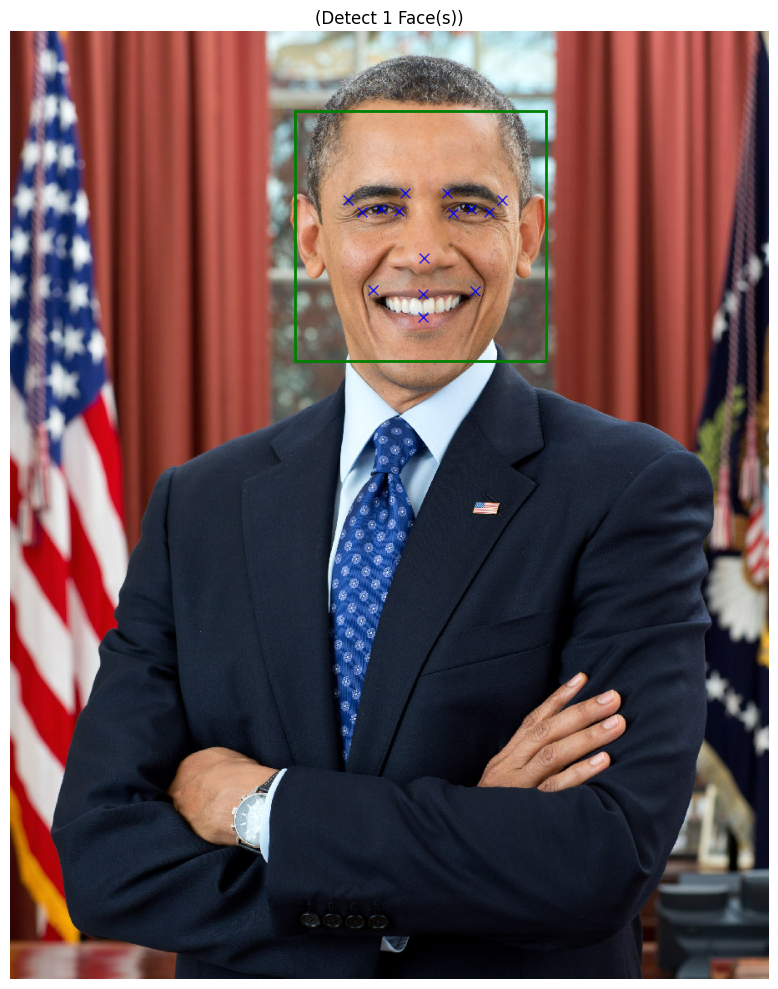

In [8]:
#HW2 - 結合 Haar Face Detection 與 Face Key Point Detection
import cv2
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from collections import OrderedDict

# 1. 載入訓練好的模型
model_path = 'model.pth'
ckpt = torch.load(model_path, map_location=device, weights_only=False)

# 建立推論用模型實例
model = cnn_model().to(device)

# 解析 checkpoint 取得 state_dict
if isinstance(ckpt, OrderedDict):
    state_dict = ckpt
elif isinstance(ckpt, dict):
    for key in ['state_dict', 'model_state_dict', 'module_state_dict']:
        if key in ckpt:
            state_dict = ckpt[key]
            break
    else:
        state_dict = ckpt
else:
    try:
        state_dict = ckpt.state_dict()
    except AttributeError:
        raise RuntimeError('無法從 checkpoint 取得 state_dict，請確認檔案內容')

# 移除 DataParallel 的 prefix
state_dict = {
    (k.replace('module.', '') if k.startswith('module.') else k): v
    for k, v in state_dict.items()
}

model.load_state_dict(state_dict)
model.eval()

# 2. 載入 Haar Cascade 
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# 3. 讀取圖片
image_path = 'Obama.jpg'
img_original = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_original, cv2.COLOR_BGR2GRAY)

# 4. 使用 Haar Cascade 偵測人臉
faces = face_cascade.detectMultiScale(
    img_gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

# 5. 對每張偵測到的臉進行關鍵點預測
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.imshow(img_rgb)
ax.axis('off')
ax.set_title(f'(Detect {len(faces)} Face(s))', fontsize=12)

for (x, y, w, h) in faces:
    # 繪製人臉框
    rect = Rectangle((x, y), w, h, linewidth=2, edgecolor='green', facecolor='none')
    ax.add_patch(rect)
    
    # 裁切人臉區域
    face_region = img_gray[y:y+h, x:x+w]
    
    # 調整大小為 96x96 (模型輸入大小)
    face_resized = cv2.resize(face_region, (96, 96)) / 255.0
    face_resized = face_resized.astype(np.float32)
    
    # 轉換為模型輸入格式 (1, 1, 96, 96)
    face_tensor = torch.tensor(face_resized).unsqueeze(0).unsqueeze(0).to(device)
    
    # 預測關鍵點
    with torch.no_grad():
        keypoints = model(face_tensor).cpu().numpy()[0]
    
    # 將關鍵點從 [-1, 1] 轉換回 [0, 96] 座標
    keypoints_96 = keypoints * 48 + 48
    
    # 將關鍵點座標從 96x96 映射回原圖座標
    keypoints_x = keypoints_96[0::2] * (w / 96.0) + x
    keypoints_y = keypoints_96[1::2] * (h / 96.0) + y
    
    # 在原圖上繪製關鍵點
    ax.scatter(keypoints_x, keypoints_y, c='blue', s=50, marker='x', alpha=0.8, edgecolors='white', linewidths=1)
    
    # 可選：連接關鍵點形成臉部輪廓
    # 0:左眼中心, 1:右眼中心, 2:左眼內角, 3:左眼外角, 4:右眼內角, 5:右眼外角
    # 6:左眉左角, 7:左眉右角, 8:右眉左角, 9:右眉右角
    # 10:鼻尖, 11:嘴左角, 12:嘴右角, 13:嘴中心上, 14:嘴中心下
    
plt.tight_layout()
plt.show()